In [1]:
from pyvis.network import Network
import networkx as nx

In [3]:
G = nx.cycle_graph(5)

net = Network(
    notebook=True,
    cdn_resources='in_line',   # <-- important
    height="600px",
    width="100%"
)

net.from_nx(G)
# net.show("graph_example.html")


In [14]:
G1 = nx.Graph()

def set_Z(start=0):
    i = start
    while True:
        yield i
        i += 1

def cyclic_Z(start=0, n=10):
    gen = set_Z(start)
    while True:
        i = next(gen) % n
        yield i


S = cyclic_Z(0, 3)
print(next(S))
print(next(S))
print(next(S))
print(next(S))



0
1
2
0


In [5]:
a = 1
n = round(2*a) + 1

print(f"a={a} n={n} n/2={n/2}")
print("1 <= a < n/2 : " , 1 <= a < n/2)

a=1 n=3 n/2=1.5
1 <= a < n/2 :  True


In [ ]:
V = cyclic_Z(0, n)
S = [a, -a, n/2]
E = [(x, x+s) for x in V for s in S]

print(V, E)

In [1]:
from pyvis.network import Network
import networkx as nx

a = 1
n = 6
# n = 6

print(f"a={a} n={n} n/2={n/2}")
print("1 <= a < n/2 : " , 1 <= a < n/2)


Z = list(range(0, n))
S = [a, -a, n/2]
E = []
print(S)


for v in Z:
    for s in S:
        u = int(v + s) % n
        E.append((v, u))

print(E)


G = nx.Graph()

# G.add_nodes_from(Z)
G.add_edges_from(E)

for node in G.nodes():
    G.nodes[node]['label'] = str(node)


net = Network(
    notebook=True,
    cdn_resources='in_line',   # <-- important
    height="600px",
    width="100%"
)

net.from_nx(G)
# net.barnes_hut()
# net.force_atlas_2based()
# pos = nx.spring_layout(G, seed=42)

# net.show("graph_example.html")
# nx.draw(G, with_labels = True)



a=1 n=6 n/2=3.0
1 <= a < n/2 :  True
[1, -1, 3.0]
[(0, 1), (0, 5), (0, 3), (1, 2), (1, 0), (1, 4), (2, 3), (2, 1), (2, 5), (3, 4), (3, 2), (3, 0), (4, 5), (4, 3), (4, 1), (5, 0), (5, 4), (5, 2)]


In [5]:
import numpy as np

n = 8
n_half = int(n/2)

for a in range(n_half):
    gcd = np.gcd(a, n_half)
    condition = (1 <= a < n_half and gcd == 1)
    
    if condition:
        print(f"1 <= {a} < {n/2} && {gcd} == 1 : gcd={gcd} a={a} n={n}" , condition)

1 <= 1 < 4.0 && 1 == 1 : gcd=1 a=1 n=8 True
1 <= 3 < 4.0 && 1 == 1 : gcd=1 a=3 n=8 True


In [2]:
n = 16
a = 5

G = nx.circulant_graph(n, [a, -a, int(n/2)])


for node in G.nodes():
	G.nodes[node]['label'] = str(node)

net = Network(
	notebook=True,
	cdn_resources='in_line',   # <-- important
	height="600px",
	width="100%"
)

net.from_nx(G)

# net.barnes_hut()
# net.force_atlas_2based()
# pos = nx.spring_layout(G, seed=42)


# print(G.nodes)


# for node in G.nodes:
#     print(f"N(f{node}) = ", list(nx.all_neighbors(G, node)))


# n1 = G.nodes[0]
# n1["infected"] = True
# print(n1.get("infected"))
print(G)


G.nodes[3]["infected"] = True
G.nodes[4]["infected"] = True

import time

def is_infectable(node):
	node_N = list(nx.all_neighbors(G, node))
	if len(node_N) < 2:
		return False
	infected_N_counter = 0
	for i_neighbor in node_N:
		if G.nodes[i_neighbor].get("infected"):
			infected_N_counter += 1
	return (infected_N_counter >= 2)



def fully_endemic(G):
	infected_nodes = [n for n in G.nodes if G.nodes[n].get("infected")]
	healthy_nodes = [n for n in G.nodes if not G.nodes[n].get("infected")]

	itter_number = 0
	while len(healthy_nodes) > 0:
		for node in healthy_nodes:
			if is_infectable(node):
				G.nodes[node]["infected"] = True
				infected_nodes.append(node)
				healthy_nodes.remove(node)

		itter_number+=1
		
		print("itter number=", itter_number, "infected_nodes:", infected_nodes, "healthy_nodes", healthy_nodes)
	
		if itter_number > n:
			break




fully_endemic(G)

Graph with 16 nodes and 24 edges
itter number= 1 infected_nodes: [3, 4] healthy_nodes [0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
itter number= 2 infected_nodes: [3, 4] healthy_nodes [0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
itter number= 3 infected_nodes: [3, 4] healthy_nodes [0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
itter number= 4 infected_nodes: [3, 4] healthy_nodes [0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
itter number= 5 infected_nodes: [3, 4] healthy_nodes [0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
itter number= 6 infected_nodes: [3, 4] healthy_nodes [0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
itter number= 7 infected_nodes: [3, 4] healthy_nodes [0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
itter number= 8 infected_nodes: [3, 4] healthy_nodes [0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
itter number= 9 infected_nodes: [3, 4] healthy_nodes [0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
itter number= 10 infected_nodes: [3, 4] healthy_n

Graph with 18 nodes and 27 edges is not isomophic
a=1 n=18
Graph with 18 nodes and 27 edges is not isomophic
a=2 n=18
Graph with 18 nodes and 27 edges is isomophic
a=4 n=18
Graph with 18 nodes and 27 edges is isomophic
a=5 n=18
Graph with 18 nodes and 27 edges is isomophic
a=7 n=18
Graph with 18 nodes and 27 edges is isomophic
a=8 n=18
number of graphs:  2


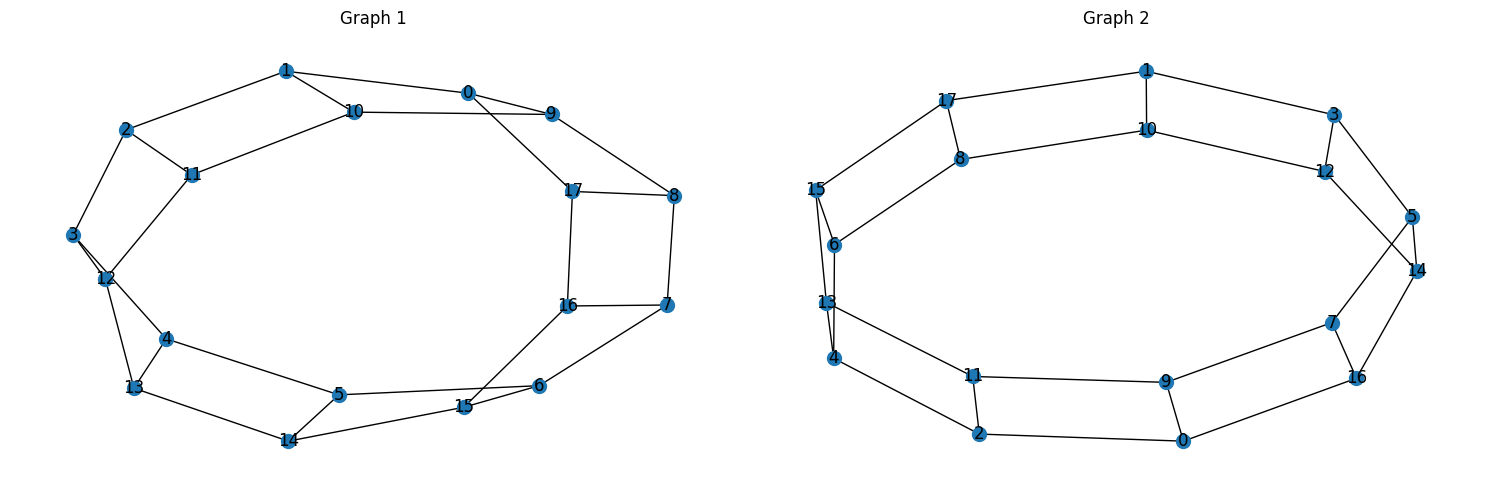

In [143]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math


n = 18
n_half = int(n/2)

graphs = []

def add_candidate_graph(H):
    global graphs
    for G_i in graphs:
        if nx.is_isomorphic(G_i, H):
            print(H, "is isomophic")
            return

    print(H, "is not isomophic")
    graphs.append(H)

for a in range(n_half):
    gcd = np.gcd(a, n_half)
    condition = (1 <= a < n_half and gcd == 1)
    
    if condition:
        g = nx.circulant_graph(n, [a, -a, n_half])
        add_candidate_graph(g)
        print(f"a={a} n={n}")

print("number of graphs: ", len(graphs))

def axes_division(x):
    factor1 = 1
    for i in range(1, int(math.sqrt(x))+1):
        if x % i == 0:
            factor1 = i
    return int(factor1), int(x/factor1)


rows, cols = axes_division(len(graphs))

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))

# fix: flatten the plot axes
axes = np.array(axes).flatten()

for i, (G, ax) in enumerate(zip(graphs, axes)):
    pos = nx.spring_layout(G, seed=100)
    nx.draw(G, pos, ax=ax, with_labels=True, node_size=100)
    ax.set_title(f"Graph {i+1}")

plt.tight_layout()
plt.show()


In [144]:
print("number of graphs: ", len(graphs))
for i in graphs:
    print(i)

print(len(graphs))
with open("all_graphs.g6", "w") as f:
    for G in graphs:
        f.write(nx.to_graph6_bytes(G).decode().strip() + "\n")


number of graphs:  2
Graph with 18 nodes and 27 edges
Graph with 18 nodes and 27 edges
2


In [209]:
c = 0

def infect_graph(vertex_list, infection_number, z=0):
    global c
    # ustavitveni pogoj
    # print(infection_number, vertex_list)
    c += 1
    if infection_number == 0:
        # print(vertex_list)
        # run the infect function
        yield vertex_list
    
    # rekurzivni klic
    for i, e in enumerate(vertex_list):
        if i < z:       # if over the duplication index
            continue
        if e:           # if it is already infected
            continue
        else:
            vertex_list_i = vertex_list[:]
            vertex_list_i[i] = 1
            # print(" " * infection_number + "(", infection_number, ") : i=", i, "e=", e, "Vi=", vertex_list_i)
            yield from infect_graph(vertex_list_i, infection_number-1, i)


x = 4
V = [0 for _ in range(x)]

pv = infect_graph(V, int(x/2))

print(type(pv))
print(next(pv))
print(next(pv))
print(next(pv))
print(next(pv))
print(next(pv))
print(next(pv))

print(c)

<class 'generator'>
[1, 1, 0, 0]
[1, 0, 1, 0]
[1, 0, 0, 1]
[0, 1, 1, 0]
[0, 1, 0, 1]
[0, 0, 1, 1]
15


In [179]:
def _binary_counter(depth=0):
    print(f'First "yield" at depth {depth}.')
    yield "1", depth
    for prefix, d in _binary_counter(depth+1):
        print(f'First recursive "yield" at depth {depth}.')
        yield prefix + "0", d
        print(f'Second recursive "yield" at depth {depth}.')
        yield prefix + "1", d

while True:
    value, depth = _binary_counter()
    print(f"value: {value}, depth: {depth}")
    if value == "1000":
        break


First "yield" at depth 0.
First "yield" at depth 1.
First recursive "yield" at depth 0.
Second recursive "yield" at depth 0.


ValueError: too many values to unpack (expected 2)

In [170]:

def show_stack():
    stack = inspect.stack()
    depth = len(stack)
    print("Call Stack\n==========")
    for i, frame in enumerate(reversed(stack)):
        indent = "  " * i
        print(f"{indent}↳ {frame.function}  ({frame.filename}:{frame.lineno})")


def a():
    b()

def b():
    c()

def c():
    show_stack()

a()


Call Stack
↳ _run_module_as_main  (/usr/lib/python3.10/runpy.py:196)
  ↳ _run_code  (/usr/lib/python3.10/runpy.py:86)
    ↳ <module>  (/home/matej/faks/3. letnik/Teorija grafov EN (izbirni)/research paper/.venv/lib/python3.10/site-packages/ipykernel_launcher.py:18)
      ↳ launch_instance  (/home/matej/faks/3. letnik/Teorija grafov EN (izbirni)/research paper/.venv/lib/python3.10/site-packages/traitlets/config/application.py:1075)
        ↳ start  (/home/matej/faks/3. letnik/Teorija grafov EN (izbirni)/research paper/.venv/lib/python3.10/site-packages/ipykernel/kernelapp.py:758)
          ↳ start  (/home/matej/faks/3. letnik/Teorija grafov EN (izbirni)/research paper/.venv/lib/python3.10/site-packages/tornado/platform/asyncio.py:211)
            ↳ run_forever  (/usr/lib/python3.10/asyncio/base_events.py:603)
              ↳ _run_once  (/usr/lib/python3.10/asyncio/base_events.py:1909)
                ↳ _run  (/usr/lib/python3.10/asyncio/events.py:80)
                  ↳ preserve_context

In [205]:

def infect_graph(vertex_list, infection_number, z=0):
    if infection_number == 0:
        print(vertex_list)
    
    # rekurzivni klic
    for i, e in enumerate(vertex_list):
        if i < z:       # if over the duplication index
            continue
        if e:           # if it is already infected
            continue
        else:
            vertex_list_i = vertex_list[:]  # make a copy of an array
            vertex_list_i[i] = 1
            infect_graph(vertex_list_i, infection_number-1, i)



x = 4
V = [0 for _ in range(x)]

infect_graph(V, int(x/2))

[1, 1, 0, 0]
[1, 0, 1, 0]
[1, 0, 0, 1]
[0, 1, 1, 0]
[0, 1, 0, 1]
[0, 0, 1, 1]


In [210]:

c = 0
def print_bin_list(k, n, bin_list):
    global c
    c+=1
    #print("debug", bin_list)
    if len(bin_list) == n:
        return

    a = bin_list[:] + [1]
    #print("debug a", a)
    if sum(a) == k:
        yield a + [0] * (n-len(bin_list)-1)
    if sum(a) + n - len(bin_list) < k:
        yield None

    yield from print_bin_list(k, n, a)

    b = bin_list[:] + [0]
    #print("debug b", b)

    if sum(b) == k:
        yield b + [0] * (n-len(bin_list)-1)

    if sum(b) + n - len(bin_list):
        yield None

    yield from print_bin_list(k, n, b)


def gen_bin_list(k, n):
    g = print_bin_list(k, n, [])

    for bin_list in g:
        if bin_list == None:
            continue
        yield bin_list


g = gen_bin_list(2, 4)

for i in g:
    print(i)

print(c)

[1, 1, 0, 0]
[1, 1, 0, 0]
[1, 1, 0, 0]
[1, 0, 1, 0]
[1, 0, 1, 0]
[1, 0, 0, 1]
[0, 1, 1, 0]
[0, 1, 1, 0]
[0, 1, 0, 1]
[0, 0, 1, 1]
31


In [186]:
[0]*6

[0, 0, 0, 0, 0, 0]

In [187]:
sum([1, 2, 3])

6

In [188]:
[1, 2, 3] + [3, 4]

[1, 2, 3, 3, 4]